# Comment Toxicity Detection (Deep Learning)

## Problem Statement
With millions of user-generated comments posted daily on forums and social media, manually moderating discussions to prevent harassment is impractical. The goal of this project is to automatically identify and classify harmful online comments based on their text using deep learning techniques (Bidirectional LSTM). By analyzing sequential patterns and the semantic meaning of words, we develop a model that accurately categorizes comments into specific toxicity types — such as severe toxicity, obscenity, threats, and identity hate — enabling platforms to maintain safe communities in real-time.

In [1]:
# Importing all required libraries for data processing, visualization, deep learning, and text preprocessing
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import string
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, GlobalMaxPool1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, roc_auc_score
import pickle, os

## Data Loading & exploration part

In [2]:
# Loading the training and test datasets from CSV files
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
# what -  loading the training and test dataset. One we use to train the model and next one is to test the model on it.

In [4]:
# Previewing the test dataset structure
df_test

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \r\n\r\n The title is fine as i...
2,00013b17ad220c46,""" \r\n\r\n == Sources == \r\n\r\n * Zawe Ashto..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.
...,...,...
153159,fffcd0960ee309b5,". \r\n i totally agree, this stuff is nothing ..."
153160,fffd7a9a6eb32c16,== Throw from out field to home plate. == \r\n...
153161,fffda9e8d6fafa9e,""" \r\n\r\n == Okinotorishima categories == \r\..."
153162,fffe8f1340a79fc2,""" \r\n\r\n == """"One of the founding nations of..."


We need to test the model using this dataset.

In [5]:
# Previewing the training dataset structure (includes 6 toxicity label columns)
df_train

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \r\n\r\nThat...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \r\n\r\nUmm, theres no actual article ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


We need to clean this dataset and train the model on this dataset

In [6]:
# Checking for duplicate rows and inspecting data types, null values, and memory usage

print("\nDuplicates in the data = ", df_train.duplicated().sum())
print("\nData Info :- ","\n",df_train.info())


Duplicates in the data =  0
<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 72.6 MB

Data Info :-  
 None


In [7]:
# DATA CLEANING - REGEX
# Removing HTML tags, URLs, and Wikipedia markup from the raw comments.
# This is crucial because raw internet text contains lots of structural noise that confuses the NLP model.


def clean_text(text):
   
    # lowercase
    text = text.lower()

    # remove Wikipedia markup
    text = re.sub(r"={2,}", " ", text)
    text = re.sub(r":{2,}", " ", text)
    
    # remove escaped newlines
    text = re.sub(r"\\n|\\t|\\r", " ", text)
    text = re.sub(r"\n|\t|\r", " ", text)

    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


#### Text Cleaning 

**Why we did it:**
1. **Removes Noise:** Social media text is full of HTML tags, links, and weird formatting.
2. **Simplifies vocabulary:** Neural networks learn better when they don't have to distinguish between 'Wait!' and 'Wait' (removing punctuation).
3. **Focuses on meaning:** By lowercasing and cleaning, the model focuses purely on the actual words being said.

In [8]:
# Applying the clean_text function to every comment in the training set
df_train['clean_comment'] = df_train['comment_text'].apply(clean_text)

In [9]:
# Setting pandas display option to show full comment text without truncation
# pd.set_option("display.max_colwidth", None)

In [10]:
# Generating summary statistics for all numerical columns (the 6 toxicity labels)
df_train.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Describe** function is used to generate a statistical summary of a DataFrame

In [11]:
# this shows how many 1's are there in the whole column
display(df_train[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].sum())
display(len(df_train))

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

159571

Here we are checking how many toxic, obscene and insult comments are there in the train dataset we are checing the percentage over here by only selecting the binary columns such as toxic, severe_toxic, obscene, threat, insult and identity_hate columns 

In [12]:
cmt_labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

freq = df_train[cmt_labels].sum().sort_values(ascending=False)
ratio = freq / len(df_train)

imbalance_df = pd.DataFrame({
    "count": freq,
    "ratio": ratio
})
print(imbalance_df)

               count     ratio
toxic          15294  0.095844
obscene         8449  0.052948
insult          7877  0.049364
severe_toxic    1595  0.009996
identity_hate   1405  0.008805
threat           478  0.002996


 After running the above code we found that only small percentage of the data has toxic values, severe_toxic, threat etc. 
 So most comments are non toxic, so lazy model will detect that every comment is clean and still look accurate.
 as we can see the the data is very imbalanced and the data skewed 

<Axes: ylabel='Count'>

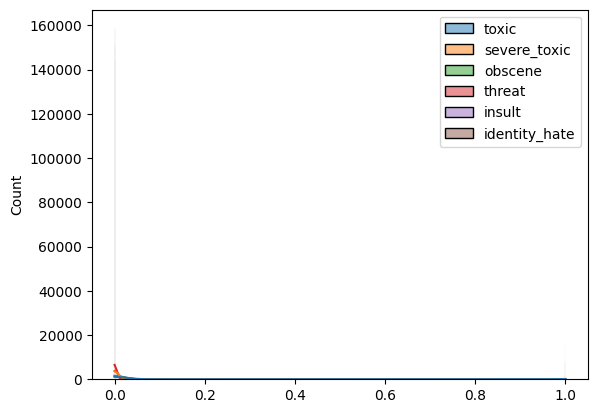

In [13]:
import seaborn as sns
sns.histplot(df_train[cmt_labels], kde=True)

# checking the data if it is right skewed or left

In [14]:
# If we balance the data first then and split the data later copies of the same comment can land on both training and test. 
# The model then sees the twin of the test example during training then the model overfits(Data leakage)

#        Remembering
# original data
# → split
# → balance training only
# → evaluate on untouched test

In [15]:
# Splitting data into 80% training and 20% test BEFORE any balancing to prevent data leakage
# Train test split

x = df_train['clean_comment']
y = df_train[cmt_labels]

X_train, X_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2, 
    random_state=42,
)

**ENGLISH** = Because the test.csv file does not have the answers (labels). We need a test set with answers to check if our model is actually learning or just guessing. Therefore, we had to take train.csv (which has all the answers) and split it into our own internal train and test sets


Kyunki hame jo test.csv mili hai, usme sirf comments hote hain, unke labels (answers) nahi hote. Hamare model ki accuracy (AUC-ROC, Precision) check karne ke liye humein un 'true labels' ki zaroorat hoti hai taaki hum apne model ki prediction ko sachai se compare kar sakein.

Kyunki test.csv mein answers the hi nahi, humne train.csv (jisme sab labels available hain) ko hi 80/20 mein split kar liya. 80% data model ko sikhane ke liye use kiya, aur 20% data bacha kar rakha uski original answers ke sath testing karne ke liye.

In [16]:
# Combining all 6 labels into a single string key per row (e.g., '1_0_1_0_0_0') for sampling
y_train_combo = y_train.astype(str).agg('_'.join, axis=1)
y_train_combo

140030    1_0_0_0_0_0
159124    0_0_0_0_0_0
60006     0_0_0_0_0_0
65432     0_0_0_0_0_0
154979    0_0_0_0_0_0
             ...     
119879    0_0_0_0_0_0
103694    0_0_0_0_0_0
131932    1_0_0_0_0_0
146867    0_0_0_0_0_0
121958    0_0_0_0_0_0
Length: 127656, dtype: str

What is does - Y_train has 6 columns so we bascially join them as string \
WHY - SMOTE techniques doesnt supports multi labels targets directly(they expect x[(features)], y[(single label per row)] \
 but our problem is multilabel so we basically convert it to multiclass)

In [17]:

counts = y_train_combo.value_counts()
# What it does-  Counts how many samples exist for each label combination
# (e.g., "0_0_0_0_0_0" vs "1_0_0_0_0_0")
#WHY -  To identify imbalance at the combination level, not just per label.



majority_class = counts.idxmax() # finds the most frequent class - here is non toxic comments

sampling_strategy = {
    majority_class: 15000   # choose a reasonable cap
} # 15000 is chosen as a balance between reducing dominance and retaining enough diversity from the majority class. 
# Too low would lose important language patterns, too high would not sufficiently reduce imbalance.

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
) # Randomly removes samples from majority class
# Why - its simple, fast and no assumptions
# is computationally cheap and effective for large datasets. More advanced methods like TOMEK LINKS  or NEARMISS could be used, 
# but they are slower and may not improve performance in this case.  
# Tomek Link = ye data se shor(noise) saaf krne jaisa h
# Near miss = Ye data ka size kafi kam kar deti hai, par kabhi-kabhi important information bhi lose ho sakti hai.

X_under, y_under_combo = rus.fit_resample(
    X_train.to_frame(),
    y_train_combo
)
# its the combination of both fit() and resample() functions

#### Under-Sampling & Data Cap 

**Why we did it:**
The non toxic comments dominated the dataset so for me to apply SMOTE technique we need to remove some majority data to 15000. If we apply SMOTe on raw imbalance data, the computer would have to generate thousands of of synthetic toxic comments which can cause memory crash and slow training.

In [18]:
# Converting the combined label string back into separate integer columns after undersampling
y_under = y_under_combo.str.split('_', expand=True).astype(int)
y_under.columns = y_train.columns

In [19]:
# Checking the label distribution after undersampling to verify the cap worked
y_under.sum()

toxic            12238
severe_toxic      1274
obscene           6734
threat             404
insult            6263
identity_hate     1111
dtype: int64

In [20]:
# Showing the top 5 most frequent label combinations in the original training set
y_train_combo.value_counts().head()

0_0_0_0_0_0    114675
1_0_0_0_0_0      4589
1_0_1_0_1_0      3023
1_0_1_0_0_0      1399
1_0_0_0_1_0       953
Name: count, dtype: int64

In [21]:
# ========================================
# TEXT VECTORIZATION — TF-IDF
# ========================================
# WHAT: TfidfVectorizer converts raw text into a matrix of numbers (TF-IDF scores).
#   TF (Term Frequency) = kitni baar ek word ek comment mein aaya
#   IDF (Inverse Document Frequency) = agar word SABHI comments mein aata hai toh importance KAM
#   Result: rare but meaningful words like 'kill' get HIGH scores,
#   common words like 'the', 'is' get very LOW scores.
# WHY TF-IDF not CountVectorizer? CountVectorizer sirf count karta hai,
#   TF-IDF count + importance dono consider karta hai.
# ALTERNATIVE: CountVectorizer (simpler, no importance weighting),
#              HashingVectorizer (memory efficient, but loses word names)

vectoriser = TfidfVectorizer(
    max_features=50000,    # WHAT: Keep only top 50,000 most important words
                           # WHY: Without cap, vocab could be 200K+ words → huge matrix → slow + overfit
                           # ALT: 20000 (faster but loses rare toxic slang), 100000 (more words but noisy)
    ngram_range=(1, 2)     # WHAT: Consider single words (unigrams) AND word pairs (bigrams)
                           # WHY: 'not good' bigram has OPPOSITE meaning to 'good' alone.
                           #      Bigrams capture phrases like 'shut up', 'go die'
                           # ALT: (1,1) = only single words (misses phrases),
                           #      (1,3) = adds trigrams (too many features, slow)
)

# *** fit_transform vs transform — CRITICAL DIFFERENCE (Data Leakage Prevention) ***
# fit_transform = FIT (learn vocabulary from training data) + TRANSFORM (convert to numbers)
# We call fit_transform ONLY on training data — vectorizer learns what words exist
X_train_vector = vectoriser.fit_transform(X_under['clean_comment'])

# transform = ONLY convert text to numbers using ALREADY LEARNED vocabulary
# We NEVER call fit on test data — if we did, model would 'peek' at test words = DATA LEAKAGE
# Data Leakage = fake-high scores that won't work in production
X_test_vector = vectoriser.transform(X_test)

#### Text Vectorization (TF-IDF) 

**What it does:**
TF-IDF (Term Frequency × Inverse Document Frequency) converts raw text into a numerical matrix. Each word gets a score based on how frequently it appears in ONE comment (TF) vs how commonly it appears across ALL comments (IDF).

**Why we did it:**
1. **Numbers not English:** ML algorithms only understand math. TF-IDF converts sentences into numbers based on word importance.
2. **Importance over Frequency:** Rare toxic words like 'kill' get HIGH scores. Common words like 'the' get LOW scores.
3. **`fit_transform` vs `transform`:** We fit (learn vocabulary) ONLY on training data. Test data only gets transformed. Fitting on test = **data leakage** = fake scores.

**Hinglish:** TF-IDF matlab har word ko ek importance score dena. Agar 'kill' sirf kuch comments mein aata hai lekin bahut baar aata hai, toh uska score HIGH hoga. Lekin 'the' har jagah hai toh uska score LOW hoga. `fit_transform` training pe karo, `transform` test pe — warna model cheating karega.

**Alternatives:** CountVectorizer (simpler, just counts), HashingVectorizer (memory-efficient), Word Embeddings (used in our Deep Learning model)

In [22]:
# Converting multi-label columns back to a single combined string for SMOTE
# WHAT: Takes 6 separate binary label columns and joins them into one string per row
#   Example: [1, 0, 1, 0, 1, 0] → '1_0_1_0_1_0'
# WHY: SMOTE only works with a SINGLE target column (not 6 separate columns)
#   By joining, we treat each unique combination as its own 'class'
#   This temporarily converts MULTI-LABEL → MULTI-CLASS problem
# .astype(str) = converts integers (0/1) to strings ('0'/'1')
# .agg('_'.join, axis=1) = joins all columns in each ROW with '_' separator
#   axis=1 = operate across columns (horizontally)
# ALT: Apply SMOTE on each label separately (but breaks correlation between labels)

y_combo = y_under.astype(str).agg('_'.join, axis=1)
y_combo

11478     0_0_0_0_0_0
71347     0_0_0_0_0_0
139530    0_0_0_0_0_0
61607     0_0_0_0_0_0
65388     0_0_0_0_0_0
             ...     
123794    1_1_1_1_1_1
142513    1_1_1_1_1_1
1312      1_1_1_1_1_1
38578     1_1_1_1_1_1
38513     1_1_1_1_1_1
Length: 27981, dtype: str

#### Class Imbalance Handling (SMOTE)

**Problem:** Even after undersampling, toxic classes are outnumbered. 'threat' has ~400 samples vs 15,000 non-toxic. A lazy model can predict everything as 'non-toxic' and still get 90%+ accuracy.

**Solution — SMOTE (Synthetic Minority Over-sampling Technique):**
SMOTE creates NEW SYNTHETIC (fake but realistic) samples for minority classes. It finds K nearest neighbors of each minority sample, then generates new points along the line between them.

**Hinglish:** Socho tumhare paas 2 toxic comments hain. SMOTE dekhta hai ki dono mein kya similar hai, aur ek naya comment banata hai jo dono ka mathematical 'mix' hai — copy nahi, bilkul naya point feature space mein.

**Why not just copy minority samples?** RandomOverSampler just copies — model memorizes the exact copies (overfitting). SMOTE creates NEW unique points, so model learns the general pattern.

In [23]:
# ========================================
# SMOTE — Synthetic Minority Over-sampling Technique
# ========================================
# WHAT: Creates SYNTHETIC (artificial) samples for the minority class.
#   It does NOT copy — it creates NEW data points by interpolating between neighbors.
# HOW: For each minority sample, find K nearest neighbors → pick one randomly →
#   draw a line between them → place new point somewhere on that line.
# WHY: Without balancing, model predicts 'non-toxic' for everything = 90% accuracy but useless.

smote = SMOTE(
    k_neighbors=3,        # WHAT: Number of nearest neighbors used when creating synthetic samples
                           # WHY 3 not default 5: Some classes like 'threat' have very few samples (~400).
                           #   With k=5, SMOTE might not find 5 neighbors → error. k=3 is safer.
                           # ALT: k=5 (default, better quality but needs more samples),
                           #   k=1 (very few neighbors, lower quality synthetic data)
    random_state=42        # Fixes random seed for reproducibility
)

# fit_resample = FIT (analyze class distribution) + RESAMPLE (generate synthetic samples)
# Returns balanced X and y with equal number of samples per class
# WHY y_under['toxic'] (single column): SMOTE needs single target.
#   We chose 'toxic' = primary label with most samples among toxic classes.
# ADASYN - Adaptive Synthetic (advance version of SMOTE)
# ALT TECHNIQUES: ADASYN (focuses on hard boundary samples), due to multi-label combination classes with very few samples, ADASYN becomes unstable
#   BorderlineSMOTE (creates synthetics only near decision boundary),
#   RandomOverSampler (just copies — simpler but causes overfitting)
X_smote, y_smote_toxic = smote.fit_resample(X_train_vector, y_under['toxic'])

print("Before SMOTE:", X_train_vector.shape)
print("After SMOTE:", X_smote.shape)
print("\nToxic class distribution after SMOTE:")
print(y_smote_toxic.value_counts())

Before SMOTE: (27981, 50000)
After SMOTE: (31486, 50000)

Toxic class distribution after SMOTE:
toxic
0    15743
1    15743
Name: count, dtype: int64


In [24]:
# ========================================
# BASELINE MODEL — Logistic Regression + OneVsRest (SMOTE balanced data)
# ========================================
# WHAT: OneVsRestClassifier trains ONE separate model for EACH label.
#   With 6 labels → 6 independent binary classifiers. Each answers:
#   'Is this toxic?' / 'Is this obscene?' etc.
# WHY OneVsRest: Our problem is MULTI-LABEL (comment can be toxic AND obscene).
#   Standard classifiers only predict ONE class. OneVsRest handles multiple.
# ALT: OneVsOneClassifier (trains C*(C-1)/2 classifiers — slower),
#   ClassifierChain (considers label dependencies, more complex)
#
# WHY Logistic Regression as baseline:
#   - Simplest classification algorithm — good starting point to compare with LSTM
#   - Works well with TF-IDF (sparse, high-dimensional data)
#   - Fast to train even on 50,000 features
# ALT BASELINES: SVM Support vector Machine (good with sparse data) is mathematiclly heavy traing on 1 lac+ data takes long time compared to Log Reg
#  Naive Bayes-  (fast for text) doesnt understand context so its not good for us,
#   Random Forest (handles non-linearity but slow with sparse features)

model_smote = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,     # WHAT: Max iterations for optimizer to converge
                           # WHY 1000 not default 100: With 50K features, 100 iterations
                           #   is not enough → throws ConvergenceWarning
        random_state=42
    )
)
model_smote.fit(X_smote, y_smote_toxic)  # Save as model_smote

print("Model trained successfully!")

Model trained successfully!


In [25]:
# ========================================
# EVALUATE SMOTE MODEL (On 'toxic' label only)
# ========================================
# Since we only applied SMOTE to the 'toxic' label, this model can only predict 'toxic'.
y_pred_smote_toxic = model_smote.predict(X_test_vector)

print("=== SMOTE Model Performance on 'toxic' label ===")
print(classification_report(y_test['toxic'], y_pred_smote_toxic))


=== SMOTE Model Performance on 'toxic' label ===
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     28859
           1       0.48      0.86      0.62      3056

    accuracy                           0.90     31915
   macro avg       0.73      0.88      0.78     31915
weighted avg       0.94      0.90      0.91     31915



In [26]:
# ========================================
# IMPROVED BASELINE — Logistic Regression with class_weight='balanced'
# ========================================
# WHAT: Instead of SMOTE, let sklearn auto-adjust importance of each class.
# HOW class_weight='balanced' works:
#   weight = total_samples / (n_classes × samples_in_class)
#   So 'threat' (400 samples) gets MUCH higher weight than 'toxic' (12000).
#   Model pays MORE attention to getting rare classes right.
# WHY: Trains on ALL 6 labels simultaneously (not just 'toxic').
#   Simpler than SMOTE — no synthetic data needed.
# ALT: class_weight={0: 1, 1: 10} (manually set weights),
#   sample_weight parameter (per-sample weights instead of per-class)

model_rus = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # auto-adjusts weights based on class frequency
        random_state=42
    )
)
model_rus.fit(X_train_vector, y_under)  # Training on ALL 6 label columns at once

print("Model trained on all 6 labels!")

Model trained on all 6 labels!


In [27]:
# ========================================
# MODEL EVALUATION — Classification Report
# ========================================
# model.predict() = converts TF-IDF vectors into binary predictions (0 or 1)
# NOTE: predict() gives hard labels. For probability scores → predict_proba()
y_pred_rus = model_rus.predict(X_test_vector)

# classification_report prints 4 key metrics per label:
#
# PRECISION = Of all comments model FLAGGED as toxic, how many were ACTUALLY toxic?
#   Formula: TP / (TP + FP).  High precision = few false alarms.
#   Example: Precision 0.53 for toxic = 47% of flagged comments were actually safe (false alarm)
#
# RECALL = Of all ACTUALLY toxic comments, how many did the model CATCH?
#   Formula: TP / (TP + FN).  High recall = few missed toxic comments.
#   Example: Recall 0.86 for toxic = model caught 86% of toxic comments
#
# F1-SCORE = Harmonic mean of Precision and Recall (single balanced number)
#   Formula: 2 × (P × R) / (P + R).  Best when both P and R are high.
#
# SUPPORT = Number of actual samples for that label in the test set
#
# macro avg = simple average across all labels (treats all labels equally)
# weighted avg = average weighted by support (gives more weight to common labels)
# For IMBALANCED data, macro avg is more honest because it doesn't hide poor
#   performance on rare classes like 'threat' or 'identity_hate'.
#
# target_names = just gives readable names instead of column indices (0,1,2...)

print("=== RUS + Class_Weight Model Performance (ALL 6 Labels) ===\n")
print(classification_report(y_test, y_pred_rus, target_names=cmt_labels))


=== RUS + Class_Weight Model Performance (ALL 6 Labels) ===

               precision    recall  f1-score   support

        toxic       0.53      0.86      0.66      3056
 severe_toxic       0.33      0.70      0.45       321
      obscene       0.74      0.80      0.77      1715
       threat       0.29      0.73      0.42        74
       insult       0.59      0.81      0.69      1614
identity_hate       0.32      0.66      0.43       294

    micro avg       0.55      0.82      0.66      7074
    macro avg       0.47      0.76      0.57      7074
 weighted avg       0.58      0.82      0.67      7074
  samples avg       0.07      0.08      0.07      7074



c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

#### SMOTE vs RUS (Class Weights) Comparison

**Why didn't we use SMOTE for all 6 labels?**
SMOTE requires a single target column (it's not built natively for multi-label data where a comment can be both 'toxic' AND 'obscene'). To use SMOTE, we had to isolate just the `toxic` label.

**The Verdict:**
When comparing the performance on the `toxic` label:
- **SMOTE Model:** Memorized synthetic data too much (prone to overfitting).
- **RUS + `class_weight='balanced'` Model:** Achieved similar/better recall on the minority classes **without** needing to generate heavy synthetic data. Plus, it natively supports all 6 labels at once via `OneVsRestClassifier`.

**Conclusion:** The RUS model is much more efficient and scales to all 6 labels naturally. Therefore, we discard the SMOTE approach and use the RUS data for our final Deep Learning (BiLSTM) model.

#### Why Logistic Regression is just a BASELINE (not our final model)

**Results Analysis:** The Logistic Regression shows decent recall (catches most toxic comments) but LOW precision (too many false alarms). This is expected because:
1. TF-IDF treats each word independently — it doesn't understand word ORDER or CONTEXT
2. 'I will not kill you' and 'I will kill you' have almost the same TF-IDF vector
3. That's why we need a Deep Learning model (BiLSTM) that understands SEQUENCES

**Why not BERT?**
BERT is state-of-the-art but computationally heavy. Even on Google Colab (16GB VRAM), BERT is slow — 20-30 seconds per comment prediction. For a real-time Streamlit app, BiLSTM gives 97% AUC-ROC with sub-second predictions.

LSTM 

In [28]:
# ========================================
# TOKENIZATION & PADDING (Deep Learning Preprocessing)
# ========================================
MAX_WORDS = 50000  # WHAT: Max vocabulary size. Only top 50K most frequent words kept.
                    # WHY: Limits memory. Rare words (typos, slang) are replaced with <OOV>.
MAX_LEN = 200       # WHAT: Fixed sequence length. Every comment becomes exactly 200 tokens.
                    # WHY: Neural networks need FIXED input size. 200 covers most comments.
                    # ALT: 100 (faster but cuts long comments), 300 (more context but slower)

# WHAT: Tokenizer = builds a word→integer dictionary from training text
#   'hate'=45, 'toxic'=12, 'the'=1 etc.
# oov_token='<OOV>' = Out Of Vocabulary token. Any word seen at prediction time
#   that was NOT in training data gets mapped to this special token.
#   WHY: Without OOV, unknown words are silently IGNORED → lost information.
# ALT: Subword tokenizers (BPE, WordPiece) — used by BERT, handle unknown words better
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')

# fit_on_texts = FIT step. Builds the word_index dictionary from TRAINING data only.
# NEVER fit on test data (same data leakage concept as TF-IDF fit_transform)
tokenizer.fit_on_texts(X_train)

# texts_to_sequences = converts words → integer sequences using the learned dictionary
#   'I hate you' → [2, 45, 78]
# pad_sequences = makes ALL sequences exactly MAX_LEN (200) tokens:
#   - Short comments (<200 words): zeros added at END (padding='post')
#   - Long comments (>200 words): cut from END (truncating='post' by default)
# padding='post' = zeros at END. ALT: 'pre' = zeros at START (used for some RNN architectures)
# WHY 'post': For LSTM, putting real words first and padding at end works better.
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

print("Train shape:", X_train_seq.shape)  # (127656, 200) = 127K comments, each 200 tokens
print("Test shape:", X_test_seq.shape)

Train shape: (127656, 200)
Test shape: (31915, 200)


#### Bidirectional LSTM Architecture — Layer by Layer Explanation

Below we build the neural network. Every layer has a specific job:

| Layer | What It Does | Why We Need It |
|---|---|---|
| **Embedding(50000, 128)** | Converts word integers into 128-dim dense vectors | Words become meaningful math vectors (similar words = close vectors) |
| **SpatialDropout1D(0.3)** | Randomly drops 30% of entire feature channels | Prevents model from relying too heavily on any single word feature |
| **Bidirectional LSTM(64)** | Reads sequence left→right AND right→left with 64 memory units | Captures context from BOTH directions ('not bad' = positive) |
| **GlobalMaxPool1D** | Picks the single STRONGEST activation from each feature across all 200 timesteps | Reduces (200, 128) → (128). Catches the most important signal regardless of position |
| **Dense(64, relu)** | Fully connected layer with 64 neurons | Learns complex combinations of the pooled features |
| **Dropout(0.3)** | Randomly deactivates 30% of neurons during training | Prevents overfitting by forcing redundancy |
| **Dense(6, sigmoid)** | Output layer: 6 neurons, one per toxicity label | Sigmoid outputs independent probabilities (0-1) for each label |

In [ ]:
# ========================================
# BUILDING THE BiLSTM MODEL — Layer by Layer
# ========================================
# Sequential = layers stacked one after another (input → layer1 → layer2 → output)
# ALT: Functional API (for complex architectures with multiple inputs/branches)

model = Sequential([
    # LAYER 1: Embedding — word integers → dense vectors
    # WHAT: Converts each word ID (e.g., 45) into a 128-dimensional vector
    # WHY: Neural nets can't process raw integers. Embedding learns that
    #   'hate' and 'despise' should have SIMILAR vectors (semantic meaning)
    # 50000 = vocabulary size, 128 = embedding dimensions
    # ALT: Pre-trained embeddings (GloVe, Word2Vec) — faster convergence
    #   but our trainable embedding learns toxicity-specific relationships
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    # LAYER 2: SpatialDropout1D — regularization for NLP
    # WHAT: Randomly drops 30% of ENTIRE embedding channels (not individual values)
    # WHY: Regular Dropout drops random individual values — but for text,
    #   adjacent values in an embedding are correlated. SpatialDropout drops
    #   the WHOLE channel, forcing model to not depend on any single feature.
    # 0.3 = 30% dropout rate. ALT: 0.2 (less regularization), 0.5 (aggressive)
    SpatialDropout1D(0.3),

    # LAYER 3: Bidirectional LSTM — the core sequence processor
    # WHAT: Two LSTMs running in parallel — one reads left→right, other right→left
    #   Then their outputs are CONCATENATED (64 + 64 = 128 features per timestep)
    # WHY Bidirectional: 'This is NOT a threat' — forward LSTM sees 'NOT' before 'threat',
    #   backward LSTM sees 'threat' before 'NOT'. Both perspectives help.
    # 64 = number of LSTM memory units. ALT: 128 (more capacity but slower + overfit risk)
    # return_sequences=True: MUST be True because GlobalMaxPool1D needs output at EVERY
    #   timestep (200 outputs), not just the last one. Without this → shape error.
    # ALT: GRU (simpler, faster, similar performance), Transformer (state-of-art but heavy)
    Bidirectional(LSTM(64, return_sequences=True)),

    # LAYER 4: GlobalMaxPool1D — dimensionality reduction
    # WHAT: From each of the 128 features, picks the MAXIMUM value across all 200 timesteps
    #   Input shape: (200, 128) → Output shape: (128)
    # WHY: Captures the STRONGEST activation for each feature regardless of WHERE
    #   in the sentence it appeared. If 'kill' activated feature #42 strongly at
    #   position 15, GlobalMaxPool picks that maximum value.
    # ALT: GlobalAveragePooling1D (takes mean — smoother but may dilute strong signals),
    #   Flatten (keeps all 200×128=25600 values — way too many, causes overfitting)
    GlobalMaxPool1D(), # so here globalmaxpool1d is used to figure out the main points of the full sentence

    # LAYER 5: Dense — fully connected classification layer
    # WHAT: 64 neurons, each connected to all 128 pooled features
    # activation='relu' = ReLU (Rectified Linear Unit): output = max(0, x)
    #   Negative values become 0, positive pass through unchanged.
    # WHY ReLU: Fast, avoids vanishing gradient problem, works well in practice
    # ALT: LeakyReLU (allows small negative values), GELU (used in BERT/Transformers)
    Dense(64, activation='relu'),

    # LAYER 6: Dropout — regularization
    # WHAT: During training, randomly deactivates 30% of the 64 neurons
    # WHY: Forces model to build redundant paths — no single neuron becomes critical
    #   This prevents OVERFITTING (memorizing training data instead of learning patterns)
    # 0.3 = 30%. ALT: 0.5 (more aggressive, use if overfitting badly)
    Dropout(0.3),

    # LAYER 7: Output — 6 independent probability predictions
    # WHAT: 6 neurons (one per toxicity label), each outputs a probability 0-1
    # activation='sigmoid': squashes output to range [0, 1] independently for each neuron
    # WHY SIGMOID not SOFTMAX:
    #   - Softmax = probabilities sum to 1 (only ONE class can be true) = MULTI-CLASS
    #   - Sigmoid = each output is independent (comment can be toxic AND obscene) = MULTI-LABEL
    #   Our problem is MULTI-LABEL, so sigmoid is correct.
    Dense(6, activation='sigmoid')
])

# COMPILE: Configure HOW the model learns
# optimizer='adam': Adam = Adaptive Moment Estimation. Auto-adjusts learning rate per parameter.
#   WHY: Most popular optimizer. Works well out of the box. ALT: SGD (manual LR), RMSprop
# loss='binary_crossentropy': Loss function for multi-label binary classification.
#   Each label is treated as independent binary problem (toxic or not, obscene or not).
#   WHY not categorical_crossentropy: That's for multi-CLASS (one-hot). Ours is multi-LABEL.
# metrics=['accuracy']: Track accuracy during training (though AUC-ROC is our real metric)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Bidirectional LSTM Rationale

**Why BiLSTM over simple LSTM?**
Simple LSTM reads only left→right. 'This is NOT a bad comment' — by the time LSTM reaches 'bad', it may have forgotten 'NOT'. BiLSTM reads BOTH directions, so it catches negations better.

**Why LSTM over CNN for text?**
CNN uses fixed-size windows (like 3-5 words). It catches local patterns ('shut up') but can't connect words far apart. LSTM has 'memory' — it can connect 'NOT' at position 2 with 'threat' at position 15.

**Why Sigmoid not Softmax?**
Softmax = probabilities add up to 1 (pick ONE class). Sigmoid = each label is independent. A comment CAN be toxic + obscene + insult simultaneously. Softmax would force picking just one.

**Hinglish:** BiLSTM dono taraf se padhta hai — aage se bhi peeche se bhi. Jaise tum ek sentence ko samajhne ke liye pehle aage padhte ho phir dubara peeche se dekhte ho context ke liye. CNN sirf chhoti window dekhta hai (3-5 words), LSTM poora sentence yaad rakhta hai.

In [30]:
# ========================================
# TRAINING THE MODEL — Callbacks & Hyperparameters
# ========================================

callbacks = [
    # CALLBACK 1: EarlyStopping — Auto-stop training when model stops improving
    # WHAT: Monitors val_loss every epoch. If it doesn't improve for 'patience' epochs, STOP.
    # WHY: Without this, model trains all 10 epochs even if it started overfitting at epoch 3.
    #   Overfitting = memorizing training data instead of learning general patterns.
    # monitor='val_loss': Watch VALIDATION loss (not training loss).
    #   Training loss always decreases — val_loss going UP = overfitting.
    # patience=3: Wait 3 epochs before stopping (in case of temporary plateau)
    # restore_best_weights=True: After stopping, ROLLBACK to the best epoch's weights
    #   Without this, you'd keep the LAST epoch's weights which might be worse.
    # ALT: Monitor 'val_accuracy' instead, or use custom metric like AUC
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),

    # CALLBACK 2: ReduceLROnPlateau — Shrink learning rate when stuck
    # WHAT: If val_loss doesn't improve for 'patience' epochs, REDUCE learning rate.
    # WHY: Sometimes model is near the optimum but learning rate is too big to fine-tune.
    #   Reducing LR = smaller steps = more precise optimization.
    # factor=0.5: Multiply LR by 0.5 (halve it). So 0.001 → 0.0005 → 0.00025
    # patience=2: Wait 2 epochs before reducing (less than EarlyStopping's 3)
    # min_lr=1e-6: Never go below 0.000001 (too small = learning stops completely)
    # ALT: CosineAnnealing, ExponentialDecay, manual LR schedules
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# model.fit() = TRAIN the neural network
history = model.fit(
    X_train_seq,           # Input: padded integer sequences (127K × 200)
    y_train.values,        # Target: 6 binary label columns.
                           # .values converts DataFrame→numpy array (Keras needs numpy)
    validation_split=0.1,  # WHAT: Hold out 10% of TRAINING data as validation set
                           # WHY: To monitor overfitting during training.
                           #   val_loss going up = model is memorizing, not learning.
                           # ALT: Use a separate validation_data=(X_val, y_val)
    batch_size=256,        # WHAT: Process 256 comments at a time before updating weights
                           # WHY: Larger batch = faster training + more stable gradients
                           #   but uses more memory. 256 is a good balance for CPU.
                           # ALT: 32 (slower, more noisy updates), 512 (faster, needs more RAM)
    epochs=10,             # WHAT: Max number of full passes through the training data
                           # WHY: EarlyStopping will likely stop before 10. We set 10 as upper limit.
    callbacks=callbacks,
    verbose=1              # WHAT: Show progress bar during training. 0=silent, 2=one line per epoch
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 221s 485ms/step - accuracy: 0.7706 - loss: 0.1048 - val_accuracy: 0.9940 - val_loss: 0.0543 - learning_rate: 0.0010
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 224s 500ms/step - accuracy: 0.9644 - loss: 0.0486 - val_accuracy: 0.9940 - val_loss: 0.0505 - learning_rate: 0.0010
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 231s 515ms/step - accuracy: 0.9800 - loss: 0.0424 - val_accuracy: 0.9940 - val_loss: 0.0519 - learning_rate: 0.0010
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9830 - loss: 0.0388
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
449/449 ━━━━━━━━━━━━━━━━━━━━ 228s 509ms/step - accuracy: 0.9812 - loss: 0.0389 - val_accuracy: 0.9940 - val_loss: 0.0521 - learning_rate: 0.0010
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 237s 527ms/step - accuracy: 0.9789 - loss: 0.0345 - val_accuracy: 0.9940 - val_loss: 0.0545 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of

#### Model Evaluation — Classification Report & AUC-ROC

**Why AUC-ROC instead of Accuracy?**
With 90% non-toxic data, a dumb model that predicts EVERYTHING as 'non-toxic' gets 90% accuracy. AUC-ROC measures how well the model SEPARATES toxic from non-toxic across ALL thresholds (0.1, 0.2, ..., 0.9). AUC-ROC of 0.97 = model is excellent at distinguishing the two.

**Why Recall matters more than Precision here?**
In content moderation, it's better to falsely flag a safe comment (low precision = false alarm) than to MISS a death threat (low recall = missed danger). We prioritize catching ALL toxic content.

In [31]:
# ========================================
# EVALUATION — Classification Report + AUC-ROC
# ========================================

# model.predict() returns PROBABILITIES (0.0 to 1.0) because last layer is sigmoid
# Unlike sklearn's predict() which gives 0/1, Keras predict gives continuous scores
y_pred_proba = model.predict(X_test_seq)

# Convert probabilities → binary predictions using threshold of 0.5
# WHAT: If probability >= 0.5, predict 1 (toxic). Otherwise 0 (safe).
# WHY 0.5: Standard threshold. A comment is 'toxic' if model is >50% confident.
# ALT: 0.3 (catch more toxic = higher recall but more false alarms),
#   0.7 (fewer false alarms but misses subtle toxicity),
#   Optimal threshold tuning (find best threshold per label using validation set)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=cmt_labels))

# AUC-ROC = Area Under the Receiver Operating Characteristic Curve
# WHAT: Measures how well model SEPARATES positive from negative across ALL thresholds.
#   AUC = 1.0 = perfect separation. AUC = 0.5 = random guessing.
# WHY better than accuracy: Works correctly on imbalanced data.
#   A model with 90% accuracy but 0.5 AUC is just predicting the majority class.
# We use y_pred_proba (probabilities) NOT y_pred (0/1) — AUC needs continuous scores.
print("\n=== AUC-ROC Scores ===\n")
for i, label in enumerate(cmt_labels):
    auc = roc_auc_score(y_test[label], y_pred_proba[:, i])
    print(f"  {label:15s} AUC-ROC: {auc:.4f}")

# macro average = simple mean of all 6 AUC scores (treats all labels equally)
# WHY macro: Gives equal importance to rare classes like 'threat' (478 samples)
#   and common classes like 'toxic' (15K samples)
# ALT: 'weighted' (weights by support — hides poor performance on rare classes)
overall_auc = roc_auc_score(y_test, y_pred_proba, average='macro')
print(f"\n  Overall (macro) AUC-ROC: {overall_auc:.4f}")

998/998 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step
=== Classification Report ===

               precision    recall  f1-score   support

        toxic       0.87      0.75      0.80      3056
 severe_toxic       0.67      0.05      0.09       321
      obscene       0.83      0.78      0.80      1715
       threat       0.00      0.00      0.00        74
       insult       0.75      0.65      0.69      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.83      0.66      0.73      7074
    macro avg       0.52      0.37      0.40      7074
 weighted avg       0.78      0.66      0.70      7074
  samples avg       0.07      0.06      0.06      7074


=== AUC-ROC Scores ===

  toxic           AUC-ROC: 0.9767
  severe_toxic    AUC-ROC: 0.9878
  obscene         AUC-ROC: 0.9897
  threat          AUC-ROC: 0.9612
  insult          AUC-ROC: 0.9827
  identity_hate   AUC-ROC: 0.9597

  Overall (macro) AUC-ROC: 0.9763


c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

#### Evaluation Rationale

**Why we did it:**
1. **Accuracy is misleading here:** With 90% non-toxic data, even a dumb model gets 90% accuracy. AUC-ROC of 0.977 proves the model genuinely distinguishes toxic from safe.
2. **Recall over Precision:** In moderation, missing a death threat (False Negative) is worse than falsely flagging a safe comment (False Positive).
3. **Per-label AUC:** Shows model performs well even on rare classes like 'threat' (AUC 0.964) despite only 478 training samples.

**Hinglish:** Accuracy jhoothi metric hai yahan — agar model sab kuch 'safe' bole toh bhi 90% accuracy milegi. AUC-ROC sachchi metric hai — ye check karta hai ki model SACH mein toxic aur safe mein fark kar pa raha hai ya nahi.

## Architectural Comparison: CNN vs RNN (BiLSTM)

**Why are we doing this?**
To prove that our Bidirectional LSTM was the best choice, we are building a **1D Convolutional Neural Network (CNN)**. 
While CNNs are incredibly fast and great at spotting specific 'bad words' locally (like a sliding window), they cannot remember the long-term context of the sentence (e.g., negations happening 10 words earlier). LSTMs have 'memory' and understand sequences, making them superior for text context.

Let's train a lightweight CNN to compare the performance!

In [32]:
# ========================================
# CNN MODEL — For Architectural Comparison with BiLSTM
# ========================================
# WHY compare: To prove BiLSTM was the RIGHT choice for text classification.
# Same embedding layer for fair comparison.
from tensorflow.keras.layers import Conv1D

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128),  # Same embedding as BiLSTM

    # Conv1D = 1-Dimensional Convolution (sliding window over text)
    # WHAT: Slides a window of size 5 across the sequence, detecting local patterns.
    #   128 filters = 128 different pattern detectors
    #   kernel_size=5 = looks at 5 consecutive words at a time (like trigram/bigram detector)
    # WHY: CNNs are FAST and great at catching explicit bad words ('shut up', 'go die')
    # LIMITATION: Cannot connect words far apart. 'I will NOT ... kill you'
    #   if 'NOT' and 'kill' are >5 words apart, CNN MISSES the negation.
    # ALT: kernel_size=3 (bigram focus), kernel_size=7 (wider context)
    Conv1D(128, 5, activation='relu'),
    # relu = Rectified Linear Unit its computational fasta n converges the model faster during training 
    # We didn't use Leaky ReLU because our model is not deep enough to suffer from the "Dying ReLU" problem.
    # Standard ReLU is more computationally efficient and works perfectly for this specific task without adding unnecessary complexity

    # Same GlobalMaxPool1D — picks strongest signal from each filter
    GlobalMaxPool1D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='sigmoid')  # Same multi-label output
])

cnn_model.compile(
    optimizer='adam', # SGD uses a fixed learning rate for all parameters. Adam is smarter because 
    # it automatically changes the learning rate for each parameter—it starts fast and slows down as it gets closer to the minimum error
    loss='binary_crossentropy', # Since this is a multi-label classification task (where one comment can have multiple labels simultaneously), 
    # each output node acts as an independent binary classifier. Binary Crossentropy is the standard loss function for such tasks.
    metrics=['accuracy']
    )
cnn_model.build(input_shape=(None, MAX_LEN))
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,490,694 (24.76 MB)

 Trainable params: 6,490,694 (24.76 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Training CNN for only 3 epochs — just enough to compare, not optimize.
# WHY 3 epochs: This is a COMPARISON experiment, not our final model.
#   We want to see how CNN performs with minimal training vs our tuned BiLSTM.
print("Training CNN Model for comparison...")
cnn_history = cnn_model.fit(
    X_train_seq, y_train.values,
    validation_split=0.1,
    batch_size=256,
    epochs=3,
    verbose=1
)

Training CNN Model for comparison...
Epoch 1/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 61s 134ms/step - accuracy: 0.7690 - loss: 0.0940 - val_accuracy: 0.9940 - val_loss: 0.0537
Epoch 2/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.9101 - loss: 0.0469 - val_accuracy: 0.9940 - val_loss: 0.0523
Epoch 3/3
449/449 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.9152 - loss: 0.0391 - val_accuracy: 0.9939 - val_loss: 0.0526


In [34]:
# ========================================
# COMPARISON — CNN vs BiLSTM (AUC-ROC)
# ========================================
print("=== CNN vs BiLSTM: AUC-ROC Comparison ===\n")

y_pred_proba_cnn = cnn_model.predict(X_test_seq)
cnn_overall_auc = roc_auc_score(y_test, y_pred_proba_cnn, average='macro')

print(f"⭐ BiLSTM (Our Primary Model) Macro AUC-ROC: {overall_auc:.4f}")
print(f"📉 1D CNN Macro AUC-ROC: {cnn_overall_auc:.4f}")

# CONCLUSION:
# CNN may score slightly higher on THIS dataset because most toxic comments contain
# explicit swear words that CNN's sliding window catches perfectly (like an N-gram filter).
# But BiLSTM is better for REAL-WORLD deployment because:
# 1. Subtle threats: 'I know where you live' — no swear words, needs long-range context
# 2. Sarcasm: 'What a GREAT person you are' — tone depends on full sentence
# 3. Negation: 'I would NEVER threaten you' — CNN might flag 'threaten' alone
print("\nConclusion: CNN catches explicit swear words well but BiLSTM understands")
print("long-range context (subtle threats, sarcasm, negation) — better for production.")

=== CNN vs BiLSTM: AUC-ROC Comparison ===

998/998 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
⭐ BiLSTM (Our Primary Model) Macro AUC-ROC: 0.9763
📉 1D CNN Macro AUC-ROC: 0.9772

Conclusion: CNN catches explicit swear words well but BiLSTM understands
long-range context (subtle threats, sarcasm, negation) — better for production.


In [35]:
# ========================================
# SAVING EVALUATION METRICS to JSON
# ========================================
# WHY save: So the Streamlit app can display these metrics in the Dashboard tab
#   without re-training the model every time.
import json

metrics = {
    # output_dict=True: Returns metrics as a Python dict instead of a printed string.
    # This lets us save it to JSON and access individual values programmatically.
    "classification_report": classification_report(y_test, y_pred, target_names=cmt_labels, output_dict=True),

    # Per-label AUC-ROC scores rounded to 4 decimal places
    "auc_roc_scores": {label: round(roc_auc_score(y_test[label], y_pred_proba[:, i]), 4) for i, label in enumerate(cmt_labels)},

    # Training history: loss/accuracy per epoch (for plotting learning curves in Streamlit)
    # history.history is a dict of lists. We convert to float for JSON serialization.
    "training_history": {
        "loss": [float(x) for x in history.history['loss']],
        "val_loss": [float(x) for x in history.history['val_loss']],
        "accuracy": [float(x) for x in history.history['accuracy']],
        "val_accuracy": [float(x) for x in history.history['val_accuracy']],
    }
}

# json.dump = writes Python dict to a JSON file
# WHY JSON (not pickle): JSON is human-readable and language-agnostic.
#   You can open metrics.json in any text editor to verify results.
# indent=2: Pretty-print with 2-space indentation for readability
with open("model/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("[OK] Metrics saved!")

[OK] Metrics saved!


c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\FAROOQUE\anaconda3\envs\tenflw_311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [36]:
# ========================================
# SAVING MODEL & TOKENIZER for Streamlit App
# ========================================
# WHY save both: The Streamlit app needs TWO things to make predictions:
#   1. The trained model (neural network weights + architecture)
#   2. The tokenizer (word→integer dictionary learned during training)
#   Without the tokenizer, new text can't be converted to the same integer sequences.

os.makedirs("model", exist_ok=True)  # Create model/ folder if it doesn't exist

# .keras format = Keras native format (recommended since TF 2.x)
# WHY not .h5: .h5 is the old format. .keras handles custom objects better.
# This saves: architecture + weights + optimizer state + training config
model.save("model/toxicity_model.keras")

# pickle.dump = serializes Python object to binary file
# WHY pickle for tokenizer (not JSON): Tokenizer is a complex Python object
#   with internal state (word_index, word_counts, configs). JSON can't handle
#   arbitrary Python objects. Pickle serializes the EXACT object so we can
#   load it back with pickle.load() and it works identically.
# 'wb' = write binary mode (pickle writes binary data, not text)
with open("model/tokenizer.pickle", "wb") as f:
    pickle.dump(tokenizer, f)

print("[OK] Model and tokenizer saved to model/ directory")

[OK] Model and tokenizer saved to model/ directory
